# Genetic Algorithm-based Chair Design Generation with PartSDF

**Objective**: Use a pre-trained PartSDF model to decompose chairs into parts, then apply a Genetic Algorithm (GA) to recombine parts from different chairs to generate novel chair designs.

## Optimization Objectives
1. **Symmetry** — generated chairs should be left-right symmetric
2. **Overlap** — minimize undesirable part intersections
3. **Design Novelty** — create combinations that haven't existed before
4. **Aesthetic / User Rules** — enforce user-specified design constraints (e.g., spatial distribution of parts)

## Pipeline
1. Load pre-trained PartSDF model & learned latent codes / poses
2. Extract per-part latents and poses from the training set
3. Define GA: each chromosome = selection of part latents + poses from different chairs
4. Define fitness function (symmetry + overlap + novelty + aesthetic)
5. Run GA optimization
6. Visualize & export the best designs

## 0. Setup & Installation (Colab)

In [ ]:
import os, sys

IN_COLAB = 'google.colab' in sys.modules

# === EDIT THESE IF YOU FORKED THE REPO ===
GITHUB_USER = "cosjiimos"
GITHUB_REPO = "PartSDF_opti"
GITHUB_BRANCH = "main"
# =========================================

def _find_partsdf_root(start_dir):
    """Walk up from start_dir until we find experiments/chair/specs.json."""
    cur = os.path.abspath(start_dir)
    for _ in range(10):
        if os.path.isfile(os.path.join(cur, "experiments", "chair", "specs.json")):
            return cur
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent
    return None

if IN_COLAB:
    # Install dependencies
    !pip install -q trimesh scikit-image matplotlib numpy torch libigl ipywidgets

    # Clone the public repo into /content (no auth needed for public repos)
    REPO_DIR = f"/content/{GITHUB_REPO}"
    if not os.path.isdir(REPO_DIR):
        !git clone --depth 1 --branch {GITHUB_BRANCH} https://github.com/{GITHUB_USER}/{GITHUB_REPO}.git {REPO_DIR}

    # specs.json lives at <repo>/experiments/chair/ OR <repo>/PartSDF/experiments/chair/
    candidates = [REPO_DIR, os.path.join(REPO_DIR, "PartSDF")]
    PARTSDF_ROOT = None
    for c in candidates:
        if os.path.isfile(os.path.join(c, "experiments", "chair", "specs.json")):
            PARTSDF_ROOT = c
            break
    if PARTSDF_ROOT is None:
        PARTSDF_ROOT = REPO_DIR
else:
    PARTSDF_ROOT = _find_partsdf_root(os.getcwd())
    if PARTSDF_ROOT is None:
        PARTSDF_ROOT = "/home/user/bodyawarechair/PartSDF"

assert os.path.isdir(PARTSDF_ROOT), f"PARTSDF_ROOT not found: {PARTSDF_ROOT}"
assert os.path.isfile(os.path.join(PARTSDF_ROOT, "experiments", "chair", "specs.json")), \
    f"specs.json not found under {PARTSDF_ROOT}/experiments/chair/"

if PARTSDF_ROOT not in sys.path:
    sys.path.insert(0, PARTSDF_ROOT)
os.chdir(PARTSDF_ROOT)

print(f"PARTSDF_ROOT: {PARTSDF_ROOT}")
print(f"Working directory: {os.getcwd()}")


In [2]:
%matplotlib inline

import json
import copy
import random
from dataclasses import dataclass, field
from typing import List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
import trimesh
import torch
import torch.nn.functional as F

from src import workspace as ws
from src.model import get_model, get_part_latents, get_part_poses
from src.mesh import create_mesh, create_parts, SdfGridFiller
from src.utils import get_device, set_seed, get_color_parts, make_grid, compute_sdf
from src.primitives import standardize_quaternion, quaternion_to_matrix

device = get_device()
print(f"Device: {device}")

/home/user/bodyawarechair/PartSDF/src/visualization.py:33: UserWarning: PyTorch3D not found, rendering functions will not work.
  warnings.warn("PyTorch3D not found, rendering functions will not work.")


Device: cuda:0


## 1. Load Pre-trained PartSDF Model

In [3]:
# ============================================================
# Load experiment specs, model, latents, and poses
# ============================================================
expdir = "experiments/chair/"
specs = ws.load_specs(expdir)

n_parts = specs["Parts"]["NumParts"]
part_dim = specs["Parts"]["LatentDim"]
latent_dim = specs["LatentDim"]
clampD = specs["ClampingDistance"]
use_poses = specs["Parts"].get("UsePoses", False)
use_occ = specs.get("ImplicitField", "SDF").lower() in ["occ", "occupancy"]

# Determine n_shapes from the saved latent file (no need for train.json)
latent_ckpt = torch.load(
    os.path.join(expdir, "latent", "latents_2000.pth"), map_location="cpu"
)
n_shapes = latent_ckpt["weight"].shape[0]

# Load train split if available (for instance names), otherwise use indices
train_split_path = specs.get("TrainSplit", None)
if train_split_path and os.path.isfile(train_split_path):
    with open(train_split_path) as f:
        instances = json.load(f)
else:
    instances = [f"chair_{i:04d}" for i in range(n_shapes)]
    print("(train.json not found — using index-based instance names)")

print(f"Experiment: {specs['Description']}")
print(f"  {n_shapes} training shapes, {n_parts} parts, latent_dim={part_dim}")
print(f"  use_poses={use_poses}")

# Build model
model = get_model(
    specs["Network"],
    **specs.get("NetworkSpecs", {}),
    n_parts=n_parts,
    part_dim=part_dim,
    use_occ=use_occ,
).to(device)

# Load latents
latents = get_part_latents(n_shapes, n_parts, part_dim, specs.get("LatentBound", None), device=device)

# Load poses
if use_poses:
    poses = get_part_poses(n_shapes, n_parts, freeze=True, device=device, fill_nans=True)

# Load checkpoint
logs = ws.load_history(expdir)
cp_epoch = logs["epoch"]

ws.load_model(expdir, model, cp_epoch)
ws.load_latents(expdir, latents, cp_epoch)
if use_poses:
    ws.load_poses(expdir, poses)

# Freeze everything
model.eval()
for p in model.parameters():
    p.requires_grad_(False)
latents.requires_grad_(False)

print(f"\nLoaded checkpoint epoch={cp_epoch}")
print(f"Model parameters: {sum(x.nelement() for x in model.parameters()):,}")
print(f"Latent shape: ({latents.num_embeddings}, {latents.n_parts}, {latents.embedding_dim})")

# Grid filler for mesh extraction
grid_filler = SdfGridFiller(128, device)

/tmp/ipykernel_2549365/2645688770.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  latent_ckpt = torch.load(
/home/user/anaconda3/envs/physiopt/lib/python3.10/site-packa

(train.json not found — using index-based instance names)
Experiment: PartSDF on the Chair dataset.
  1065 training shapes, 8 parts, latent_dim=256
  use_poses=True

Loaded checkpoint epoch=2000
Model parameters: 873,467
Latent shape: (1065, 8, 256)


/home/user/bodyawarechair/PartSDF/src/workspace.py:224: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  history = torch.load(filename)
/home/user/bodyawarechair/PartSDF/src/wo

## 2. Extract Part Library

Build a "part library" — for each training chair, extract per-part latent codes and poses. Each gene in the GA chromosome will pick one part from this library.

In [4]:
# ============================================================
# Build part library from all training shapes
# ============================================================
# part_latents_all: (n_shapes, n_parts, latent_dim) — all learned part latents
# part_poses_all:   (n_shapes, n_parts, 10)         — [quat(4), trans(3), scale(3)]

part_latents_all = latents.weight.detach().clone()  # (n_shapes, n_parts, latent_dim)
print(f"Part latents library: {part_latents_all.shape}")

if use_poses:
    part_poses_all = poses.weight.detach().clone()  # (n_shapes, n_parts, 10)
    print(f"Part poses library:   {part_poses_all.shape}")

    # Decompose poses for convenience
    def decompose_poses(pose_tensor):
        """Split pose tensor into R (quaternion), t (translation), s (scale)."""
        R = standardize_quaternion(pose_tensor[..., :4])
        t = pose_tensor[..., 4:7]
        s = pose_tensor[..., 7:10]
        return R, t, s

    # Compute mean poses (used as fallback for NaN parts)
    mean_pose = part_poses_all.nanmean(dim=0, keepdim=True)
    nan_mask = torch.isnan(part_poses_all).any(-1)
    if nan_mask.any():
        print(f"  Found {nan_mask.sum().item()} NaN pose entries, filling with mean.")
        for p in range(n_parts):
            idx = nan_mask[:, p]
            part_poses_all[idx, p] = mean_pose[0, p]

print(f"\nPart library ready: {n_shapes} chairs x {n_parts} parts")

Part latents library: torch.Size([1065, 8, 256])
Part poses library:   torch.Size([1065, 8, 10])

Part library ready: 1065 chairs x 8 parts


## 3. Visualize Example: Original Chair & Its Parts

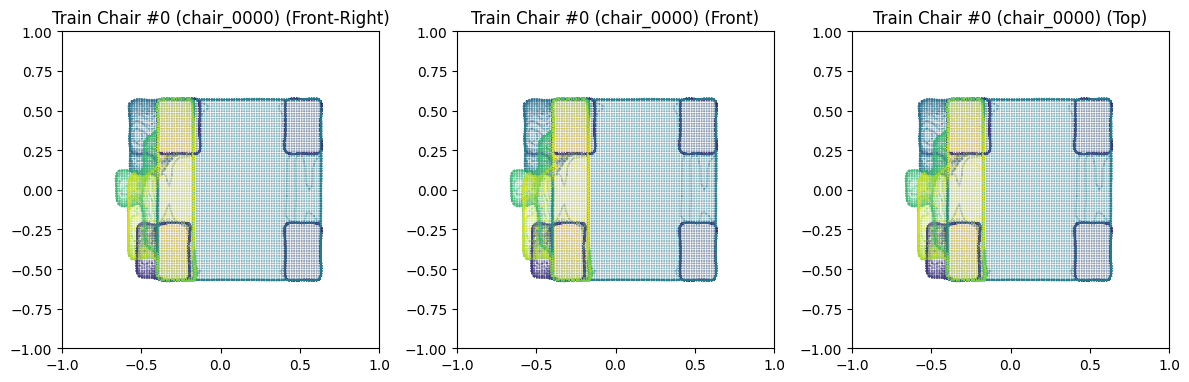

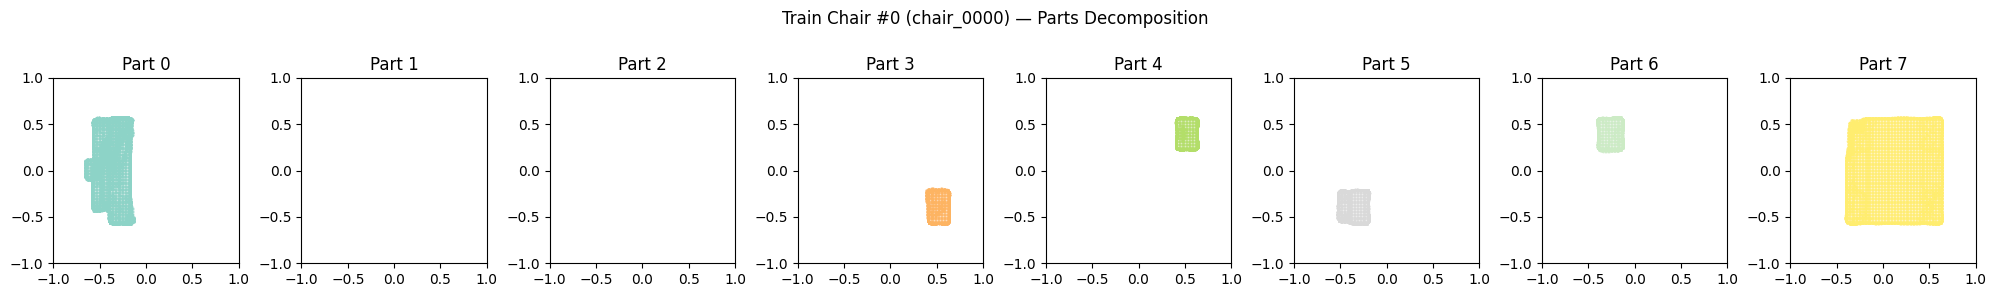

In [5]:
# ============================================================
# Visualize a training chair and its decomposed parts
# ============================================================
def decode_chair(latent, R=None, t=None, s=None, resolution=128):
    """Decode a chair from latent + pose into mesh and part meshes."""
    mesh = create_mesh(model, latent, resolution, 32**3,
                       grid_filler=grid_filler, device=device, R=R, t=t, s=s)
    parts = create_parts(model, latent, resolution, 32**3,
                         grid_filler=grid_filler, device=device, R=R, t=t, s=s)
    return mesh, parts


def visualize_chair(mesh, parts, title="Chair", figsize=(12, 4)):
    """Render a chair mesh + colored parts side by side using matplotlib."""
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # Full mesh — render as a cross-section scatter
    for ax_idx, (elev, azim, label) in enumerate([
        (30, 45, "Front-Right"), (0, 0, "Front"), (90, 0, "Top")
    ]):
        ax = axes[ax_idx]
        if not mesh.is_empty:
            verts = mesh.vertices
            ax.scatter(verts[:, 0], verts[:, 2], c=verts[:, 1],
                       cmap='viridis', s=0.1, alpha=0.5)
        ax.set_title(f"{title} ({label})")
        ax.set_aspect('equal')
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)

    fig.tight_layout()
    plt.show()

    # Parts visualization
    colors = plt.cm.Set3(np.linspace(0, 1, n_parts))
    fig2, axes2 = plt.subplots(1, n_parts, figsize=(2.5 * n_parts, 3))
    if n_parts == 1:
        axes2 = [axes2]
    for i, (part, ax) in enumerate(zip(parts, axes2)):
        if not part.is_empty:
            verts = part.vertices
            ax.scatter(verts[:, 0], verts[:, 2], c=[colors[i]], s=0.3, alpha=0.5)
        ax.set_title(f"Part {i}")
        ax.set_aspect('equal')
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
    fig2.suptitle(f"{title} — Parts Decomposition")
    fig2.tight_layout()
    plt.show()


# Show a random training chair
idx = 0
lat = latents(torch.tensor([idx]).to(device))
if use_poses:
    R, t, s = poses(torch.tensor([idx]).to(device))
else:
    R, t, s = None, None, None

mesh, parts = decode_chair(lat, R, t, s)
visualize_chair(mesh, parts, title=f"Train Chair #{idx} ({instances[idx]})")

## 4. GA Chromosome Representation

Each chromosome represents a novel chair design:
- **Genes**: For each of the `n_parts` parts, two values:
  - `latent_src`: which training chair to take the part's **shape (latent)** from
  - `pose_src`: which training chair to take the part's **pose (position/rotation/scale)** from
- **Key insight**: Mixing latents from different chairs creates novel shapes, but poses must be spatially coherent. We use a **pose anchor** strategy — by default all parts share one chair's poses as the spatial skeleton, and only the latent (intrinsic shape) varies.

### Modes:
- **Intrinsic-only** (default): Latents from different chairs, poses from a single anchor chair → parts stay in correct positions
- **Full mix**: Both latent and pose from different chairs (more freedom, but risk of floating parts)

In [6]:
# ============================================================
# Chromosome: encodes a chair as a selection of parts
# ============================================================
# NOTE: PartSDF training data uses Y-up (y = vertical). Custom assets use Z-up,
# so any externally-added asset needs a coordinate swap before being mixed in here.

# --- MODE SELECTION ---
# "intrinsic": only mix part shapes (latents), poses from a single anchor chair
# "full":      mix both latents and poses independently (may cause floating parts)
MIXING_MODE = "intrinsic"

@dataclass
class Chromosome:
    """A chromosome = one candidate chair design."""
    genes: List[int]          # length n_parts; genes[p] = chair index for part p's LATENT
    pose_anchor: int = 0      # chair index whose poses are used for ALL parts (intrinsic mode)
    fitness: float = 0.0
    evaluated: bool = False   # explicit flag; fitness==0.0 is a valid score, not a sentinel
    fitness_details: dict = field(default_factory=dict)

    def __repr__(self):
        return (f"Chromosome(genes={self.genes}, pose_anchor={self.pose_anchor}, "
                f"fitness={self.fitness:.4f})")


def random_chromosome() -> Chromosome:
    """Create a random chromosome."""
    genes = [random.randint(0, n_shapes - 1) for _ in range(n_parts)]
    pose_anchor = random.randint(0, n_shapes - 1)
    return Chromosome(genes=genes, pose_anchor=pose_anchor)


def chromosome_to_latent_pose(chrom: Chromosome):
    """
    Convert a chromosome to the latent + pose tensors needed by the model.

    In "intrinsic" mode:
      - Latent for each part comes from genes[p] (different chairs)
      - Pose for ALL parts comes from pose_anchor (single chair skeleton)
    In "full" mode:
      - Both latent and pose for part p come from genes[p]

    Returns:
        latent: (1, n_parts, latent_dim)
        R, t, s: (1, n_parts, 4/3/3) or None
    """
    # Assemble latent: pick part p's latent from chair genes[p]
    lat = torch.stack([
        part_latents_all[chrom.genes[p], p] for p in range(n_parts)
    ], dim=0).unsqueeze(0).to(device)  # (1, n_parts, latent_dim)

    if use_poses:
        if MIXING_MODE == "intrinsic":
            # All poses from the single anchor chair
            pose = part_poses_all[chrom.pose_anchor].unsqueeze(0).to(device)  # (1, n_parts, 10)
        else:
            # Each part's pose from its own source chair
            pose = torch.stack([
                part_poses_all[chrom.genes[p], p] for p in range(n_parts)
            ], dim=0).unsqueeze(0).to(device)
        R, t, s = decompose_poses(pose)
    else:
        R, t, s = None, None, None

    return lat, R, t, s


# Test: create and decode a random chromosome
test_chrom = random_chromosome()
print(f"Mode: {MIXING_MODE}")
print(f"Random chromosome: genes={test_chrom.genes}, pose_anchor={test_chrom.pose_anchor}")
lat, R, t, s = chromosome_to_latent_pose(test_chrom)
print(f"Latent shape: {lat.shape}")
if use_poses:
    print(f"Pose shapes: R={R.shape}, t={t.shape}, s={s.shape}")

Mode: intrinsic
Random chromosome: genes=[55, 985, 1036, 965, 856, 739, 555, 252], pose_anchor=714
Latent shape: torch.Size([1, 8, 256])
Pose shapes: R=torch.Size([1, 8, 4]), t=torch.Size([1, 8, 3]), s=torch.Size([1, 8, 3])


## 5. Fitness Function

The fitness function evaluates each chromosome (chair design) on 5 objectives:

1. **Symmetry Score**: Measures left-right (x-axis) symmetry of the SDF field
2. **Overlap Penalty**: Penalizes excessive intersection between parts (using part SDFs)
3. **Connectivity Score**: Ensures parts are physically connected (touching/adjacent), not floating
4. **Design Novelty**: Measures how different the design is from any single training chair
5. **Aesthetic / Spatial Distribution**: Penalizes degenerate cases (all parts at bottom, identical overlapping parts, etc.)

In [10]:
# ============================================================
# Fitness components
# ============================================================

# Pre-compute a low-res evaluation grid (shared across all fitness evals)
EVAL_RES = 32  # low res for fast fitness evaluation
eval_grid = make_grid([(-1, -1, -1), (1, 1, 1)], EVAL_RES, device=device)  # (N,N,N,3)
eval_points = eval_grid.reshape(-1, 3)  # (N^3, 3)
print(f"Evaluation grid: {EVAL_RES}^3 = {len(eval_points)} points")

# Voxel size for connectivity distance threshold
VOXEL_SIZE = 2.0 / (EVAL_RES - 1)
# Tightened from 1.5x to 1.0x voxel — requires parts to actually touch, not just be nearby.
CONNECTIVITY_THRESH_VOXELS = 1.0


@torch.no_grad()
def compute_part_sdfs(latent, R=None, t=None, s=None):
    """Compute per-part SDF values on the evaluation grid. Returns (N^3, n_parts)."""
    model.eval()
    n = len(eval_points)
    sdfs = torch.zeros(n, n_parts, device=device)
    batch_size = 32**3
    for i in range(0, n, batch_size):
        pts = eval_points[i:i+batch_size]
        # (1, batch, n_parts, 1)
        out = model(latent, pts, R=R, t=t, s=s, return_parts=True)
        sdfs[i:i+batch_size] = out.squeeze(0).squeeze(-1)
    return sdfs


def fitness_symmetry(latent, part_sdfs, R=None, t=None, s=None):
    """
    Symmetry score: compare SDF(x,y,z) vs SDF(-x,y,z).
    Reuses part_sdfs for the original-point side — composed SDF is min over parts —
    so we only need ONE extra model pass (the flipped side) instead of two.
    Returns a score in [0, 1] where 1 = perfectly symmetric.
    """
    # Composed SDF at original points: union of parts = min over parts
    sdf_orig = part_sdfs.min(dim=-1).values  # (N^3,)

    # Flipped side still needs a fresh model call
    n = len(eval_points)
    batch_size = 32**3
    sdf_flip = torch.zeros(n, device=device)
    for i in range(0, n, batch_size):
        pts_flip = eval_points[i:i+batch_size].clone()
        pts_flip[:, 0] = -pts_flip[:, 0]  # flip x
        sdf_flip[i:i+batch_size] = model(latent, pts_flip, R=R, t=t, s=s).squeeze(0).squeeze(-1)

    # Clamp to focus on near-surface region
    sdf_orig = torch.clamp(sdf_orig, -clampD, clampD)
    sdf_flip = torch.clamp(sdf_flip, -clampD, clampD)

    # Symmetry = 1 - normalized L1 difference
    diff = (sdf_orig - sdf_flip).abs().mean()
    score = 1.0 - (diff / (2 * clampD)).item()
    return max(0.0, score)


def fitness_overlap(part_sdfs):
    """
    Overlap penalty: for each point, count how many parts claim it (SDF < 0).
    Penalize points where > 1 part overlaps.
    Returns a score in [0, 1] where 1 = no overlap.
    """
    inside = (part_sdfs < 0).float()  # (N^3, n_parts)
    n_inside = inside.sum(dim=-1)     # (N^3,) — how many parts at each point
    overlap_points = (n_inside > 1).float().sum()
    any_inside = (n_inside >= 1).float().sum()

    if any_inside < 1:
        return 1.0  # no geometry at all — no overlap

    overlap_ratio = (overlap_points / any_inside).item()
    score = 1.0 - overlap_ratio
    return max(0.0, score)


def fitness_connectivity(part_sdfs):
    """
    Connectivity score: checks that parts are physically touching/adjacent.

    For each pair of active parts (i, j), we look for grid points where
    BOTH parts have small absolute SDF (near surface). If such points exist,
    the two parts are "in contact" at that region.

    Then we check that all active parts form a single connected component
    via these pairwise contacts. Disconnected floating parts are penalized.

    Returns a score in [0, 1] where 1 = all parts connected.
    """
    # A part's surface is "near" a grid point if |SDF| < threshold.
    # Using 1.0 voxels (tightened from 1.5) so we require actual contact.
    surface_thresh = VOXEL_SIZE * CONNECTIVITY_THRESH_VOXELS

    # Find which parts are active (have interior volume)
    active = []
    for p in range(n_parts):
        if (part_sdfs[:, p] < 0).any():
            active.append(p)

    n_active = len(active)
    if n_active <= 1:
        # 0 or 1 parts — trivially connected
        return 1.0 if n_active == 1 else 0.0

    # Build adjacency: two parts are adjacent if there exist points where
    # both parts' surfaces are close (|SDF_i| < thresh AND |SDF_j| < thresh)
    near_surface = part_sdfs.abs() < surface_thresh  # (N^3, n_parts) bool

    adj = set()
    for idx_i in range(len(active)):
        for idx_j in range(idx_i + 1, len(active)):
            pi, pj = active[idx_i], active[idx_j]
            contact = (near_surface[:, pi] & near_surface[:, pj]).sum().item()
            if contact > 0:
                adj.add((idx_i, idx_j))
                adj.add((idx_j, idx_i))

    # BFS to find connected components among active parts
    visited = set()
    queue = [0]  # start from first active part
    visited.add(0)
    while queue:
        node = queue.pop(0)
        for idx_j in range(len(active)):
            if idx_j not in visited and (node, idx_j) in adj:
                visited.add(idx_j)
                queue.append(idx_j)

    # Score = fraction of active parts reachable from the first part
    connectivity_ratio = len(visited) / n_active
    return connectivity_ratio


def fitness_novelty(chrom: Chromosome):
    """
    Novelty score: how different is this combination from any single training chair?
    If all genes point to the same chair, novelty = 0.
    Maximum novelty when parts come from many different chairs.
    Returns a score in [0, 1].
    """
    unique_sources = len(set(chrom.genes))

    # Base novelty from diversity of sources
    diversity = (unique_sources - 1) / max(n_parts - 1, 1)

    # Also check if this exact combination exists in training set
    # (any single-chair combo has novelty 0)
    if unique_sources == 1:
        return 0.0

    return diversity


def fitness_aesthetic(part_sdfs, chrom: Chromosome):
    """
    Aesthetic / spatial distribution score. Penalizes:
    1. All parts concentrated in one region (e.g., only bottom)
    2. Parts with no geometry (empty parts)
    3. Degenerate designs

    Returns a score in [0, 1].
    """
    # --- 1. Spatial distribution: check that parts span vertical range ---
    # PartSDF training data is Y-up, so index 1 is vertical.
    part_centroids_y = []
    for p in range(n_parts):
        inside_p = (part_sdfs[:, p] < 0)
        if inside_p.any():
            pts_inside = eval_points[inside_p]
            centroid_y = pts_inside[:, 1].mean().item()
            part_centroids_y.append(centroid_y)

    if len(part_centroids_y) >= 2:
        y_range = max(part_centroids_y) - min(part_centroids_y)
        distribution_score = min(y_range / 1.0, 1.0)
    elif len(part_centroids_y) == 1:
        distribution_score = 0.3  # only one active part
    else:
        distribution_score = 0.0  # no geometry

    # --- 2. Count active parts (parts with actual geometry) ---
    active_parts = 0
    for p in range(n_parts):
        if (part_sdfs[:, p] < 0).any():
            active_parts += 1
    active_ratio = active_parts / n_parts

    # --- 3. Penalize if too few unique source chairs ---
    unique = len(set(chrom.genes))
    source_diversity = min(unique / max(n_parts // 2, 2), 1.0)

    # Combine
    score = 0.4 * distribution_score + 0.3 * active_ratio + 0.3 * source_diversity
    return score


print("Fitness functions defined (connectivity tightened to 1.0 voxel; symmetry reuses part_sdfs).")

Evaluation grid: 32^3 = 32768 points
Fitness functions defined (connectivity tightened to 1.0 voxel; symmetry reuses part_sdfs).


In [8]:
# ============================================================
# Combined fitness evaluation
# ============================================================

# Weights for each objective (tune these!)
W_SYMMETRY     = 0.15
W_OVERLAP      = 0.20
W_CONNECTIVITY = 0.30   # high weight — parts MUST be connected
W_NOVELTY      = 0.15
W_AESTHETIC    = 0.20

def evaluate_fitness(chrom: Chromosome) -> float:
    """Evaluate the total fitness of a chromosome."""
    lat, R, t, s = chromosome_to_latent_pose(chrom)

    # Compute per-part SDFs on evaluation grid (reused by symmetry/overlap/connectivity/aesthetic)
    part_sdfs = compute_part_sdfs(lat, R, t, s)

    # Individual scores
    sym  = fitness_symmetry(lat, part_sdfs, R, t, s)
    ovl  = fitness_overlap(part_sdfs)
    conn = fitness_connectivity(part_sdfs)
    nov  = fitness_novelty(chrom)
    aes  = fitness_aesthetic(part_sdfs, chrom)

    # Weighted sum
    total = (W_SYMMETRY * sym + W_OVERLAP * ovl + W_CONNECTIVITY * conn
             + W_NOVELTY * nov + W_AESTHETIC * aes)

    chrom.fitness = total
    chrom.evaluated = True
    chrom.fitness_details = {
        'symmetry': sym, 'overlap': ovl, 'connectivity': conn,
        'novelty': nov, 'aesthetic': aes
    }
    return total


# Test fitness on a random chromosome
test_chrom = random_chromosome()
score = evaluate_fitness(test_chrom)
print(f"Chromosome: {test_chrom.genes}")
print(f"Fitness: {score:.4f}")
print(f"Details: {test_chrom.fitness_details}")

Chromosome: [330, 641, 268, 228, 941, 596, 341, 699]
Fitness: 0.9749
Details: {'symmetry': 0.9494496360421181, 'overlap': 0.9873708384111524, 'connectivity': 1.0, 'novelty': 1.0, 'aesthetic': 0.925}


## 6. Genetic Algorithm Operators

In [12]:
# ============================================================
# GA Operators: Selection, Crossover, Mutation
# ============================================================

def tournament_selection(population: List[Chromosome], k: int = 3) -> Chromosome:
    """Select the best individual from a random tournament of size k."""
    candidates = random.sample(population, min(k, len(population)))
    return max(candidates, key=lambda c: c.fitness)


def crossover_uniform(parent1: Chromosome, parent2: Chromosome) -> Tuple[Chromosome, Chromosome]:
    """Uniform crossover: each gene independently picked from either parent."""
    child1_genes = []
    child2_genes = []
    for p in range(n_parts):
        if random.random() < 0.5:
            child1_genes.append(parent1.genes[p])
            child2_genes.append(parent2.genes[p])
        else:
            child1_genes.append(parent2.genes[p])
            child2_genes.append(parent1.genes[p])
    # Pose anchor: inherit from one parent randomly
    anchor1 = parent1.pose_anchor if random.random() < 0.5 else parent2.pose_anchor
    anchor2 = parent2.pose_anchor if random.random() < 0.5 else parent1.pose_anchor
    return (Chromosome(genes=child1_genes, pose_anchor=anchor1),
            Chromosome(genes=child2_genes, pose_anchor=anchor2))


def crossover_single_point(parent1: Chromosome, parent2: Chromosome) -> Tuple[Chromosome, Chromosome]:
    """Single-point crossover."""
    point = random.randint(1, n_parts - 1)
    child1 = Chromosome(genes=parent1.genes[:point] + parent2.genes[point:],
                         pose_anchor=parent1.pose_anchor)
    child2 = Chromosome(genes=parent2.genes[:point] + parent1.genes[point:],
                         pose_anchor=parent2.pose_anchor)
    return child1, child2


def mutate(chrom: Chromosome, mutation_rate: float = 0.15) -> Chromosome:
    """Mutate: with probability mutation_rate, replace each gene with a random chair index."""
    new_genes = chrom.genes.copy()
    new_anchor = chrom.pose_anchor
    for p in range(n_parts):
        if random.random() < mutation_rate:
            new_genes[p] = random.randint(0, n_shapes - 1)
    # Also mutate pose anchor occasionally
    if random.random() < mutation_rate:
        new_anchor = random.randint(0, n_shapes - 1)
    return Chromosome(genes=new_genes, pose_anchor=new_anchor)


def mutate_swap(chrom: Chromosome) -> Chromosome:
    """Swap mutation: swap two random parts' source chairs."""
    new_genes = chrom.genes.copy()
    i, j = random.sample(range(n_parts), 2)
    new_genes[i], new_genes[j] = new_genes[j], new_genes[i]
    return Chromosome(genes=new_genes, pose_anchor=chrom.pose_anchor)


print("GA operators defined.")

GA operators defined.


## 7. Run the Genetic Algorithm

In [13]:
# ============================================================
# GA Configuration
# ============================================================
GA_CONFIG = {
    'population_size': 10,    
    'n_generations': 5,       
    'crossover_rate': 0.8,
    'mutation_rate': 0.15,
    'elitism_count': 2,       # top-N carried over unchanged
    'tournament_size': 3,
    'seed': 42,
}

set_seed(GA_CONFIG['seed'])
print("GA Configuration:")
for k, v in GA_CONFIG.items():
    print(f"  {k}: {v}")

GA Configuration:
  population_size: 10
  n_generations: 5
  crossover_rate: 0.8
  mutation_rate: 0.15
  elitism_count: 2
  tournament_size: 3
  seed: 42


In [14]:
# ============================================================
# Run GA
# ============================================================
import time

pop_size = GA_CONFIG['population_size']
n_gen = GA_CONFIG['n_generations']
cx_rate = GA_CONFIG['crossover_rate']
mut_rate = GA_CONFIG['mutation_rate']
elite_n = GA_CONFIG['elitism_count']
tourn_k = GA_CONFIG['tournament_size']

# Initialize population
population = [random_chromosome() for _ in range(pop_size)]

# History tracking
history = {
    'best_fitness': [],
    'avg_fitness': [],
    'best_symmetry': [],
    'best_overlap': [],
    'best_connectivity': [],
    'best_novelty': [],
    'best_aesthetic': [],
}

print(f"Starting GA: {pop_size} individuals x {n_gen} generations\n")
ga_start = time.time()

for gen in range(n_gen):
    gen_start = time.time()

    # --- Evaluate fitness ---
    for chrom in population:
        if not chrom.evaluated:
            evaluate_fitness(chrom)

    # Sort by fitness (descending)
    population.sort(key=lambda c: c.fitness, reverse=True)

    # Record stats
    best = population[0]
    avg_fit = np.mean([c.fitness for c in population])
    history['best_fitness'].append(best.fitness)
    history['avg_fitness'].append(avg_fit)
    history['best_symmetry'].append(best.fitness_details.get('symmetry', 0))
    history['best_overlap'].append(best.fitness_details.get('overlap', 0))
    history['best_connectivity'].append(best.fitness_details.get('connectivity', 0))
    history['best_novelty'].append(best.fitness_details.get('novelty', 0))
    history['best_aesthetic'].append(best.fitness_details.get('aesthetic', 0))

    gen_time = time.time() - gen_start
    print(f"Gen {gen:3d} | Best: {best.fitness:.4f} | Avg: {avg_fit:.4f} | "
          f"Sym={best.fitness_details['symmetry']:.3f} "
          f"Ovl={best.fitness_details['overlap']:.3f} "
          f"Con={best.fitness_details['connectivity']:.3f} "
          f"Nov={best.fitness_details['novelty']:.3f} "
          f"Aes={best.fitness_details['aesthetic']:.3f} | "
          f"{gen_time:.1f}s")

    # --- Create next generation ---
    next_gen = []

    # Elitism: carry over top individuals
    for i in range(elite_n):
        elite = copy.deepcopy(population[i])
        next_gen.append(elite)

    # Fill the rest with crossover + mutation
    while len(next_gen) < pop_size:
        parent1 = tournament_selection(population, tourn_k)
        parent2 = tournament_selection(population, tourn_k)

        if random.random() < cx_rate:
            child1, child2 = crossover_uniform(parent1, parent2)
        else:
            child1 = copy.deepcopy(parent1)
            child2 = copy.deepcopy(parent2)

        # Mutation
        child1 = mutate(child1, mut_rate)
        child2 = mutate(child2, mut_rate)

        # Occasionally apply swap mutation
        if random.random() < 0.1:
            child1 = mutate_swap(child1)
        if random.random() < 0.1:
            child2 = mutate_swap(child2)

        # Mark as unevaluated — new genotype
        child1.evaluated = False
        child2.evaluated = False
        next_gen.extend([child1, child2])

    population = next_gen[:pop_size]

# Final evaluation
for chrom in population:
    if not chrom.evaluated:
        evaluate_fitness(chrom)
population.sort(key=lambda c: c.fitness, reverse=True)

total_time = time.time() - ga_start
print(f"\nGA completed in {total_time:.1f}s")
print(f"Best fitness: {population[0].fitness:.4f}")
print(f"Best genes:   {population[0].genes}")
print(f"Details:      {population[0].fitness_details}")

Starting GA: 10 individuals x 5 generations

Gen   0 | Best: 0.9830 | Avg: 0.9708 | Sym=0.966 Ovl=0.988 Con=1.000 Nov=1.000 Aes=0.952 | 1.5s
Gen   1 | Best: 0.9860 | Avg: 0.9807 | Sym=0.968 Ovl=0.992 Con=1.000 Nov=1.000 Aes=0.963 | 1.2s
Gen   2 | Best: 0.9935 | Avg: 0.9831 | Sym=0.967 Ovl=0.992 Con=1.000 Nov=1.000 Aes=1.000 | 1.2s
Gen   3 | Best: 0.9937 | Avg: 0.9831 | Sym=0.965 Ovl=0.994 Con=1.000 Nov=1.000 Aes=1.000 | 1.2s
Gen   4 | Best: 0.9941 | Avg: 0.9867 | Sym=0.974 Ovl=0.990 Con=1.000 Nov=1.000 Aes=1.000 | 1.2s

GA completed in 7.4s
Best fitness: 0.9945
Best genes:   [329, 379, 273, 135, 449, 779, 435, 469]
Details:      {'symmetry': 0.9737336952239275, 'overlap': 0.9920844323933125, 'connectivity': 1.0, 'novelty': 1.0, 'aesthetic': 1.0}


## 8. Convergence Plots

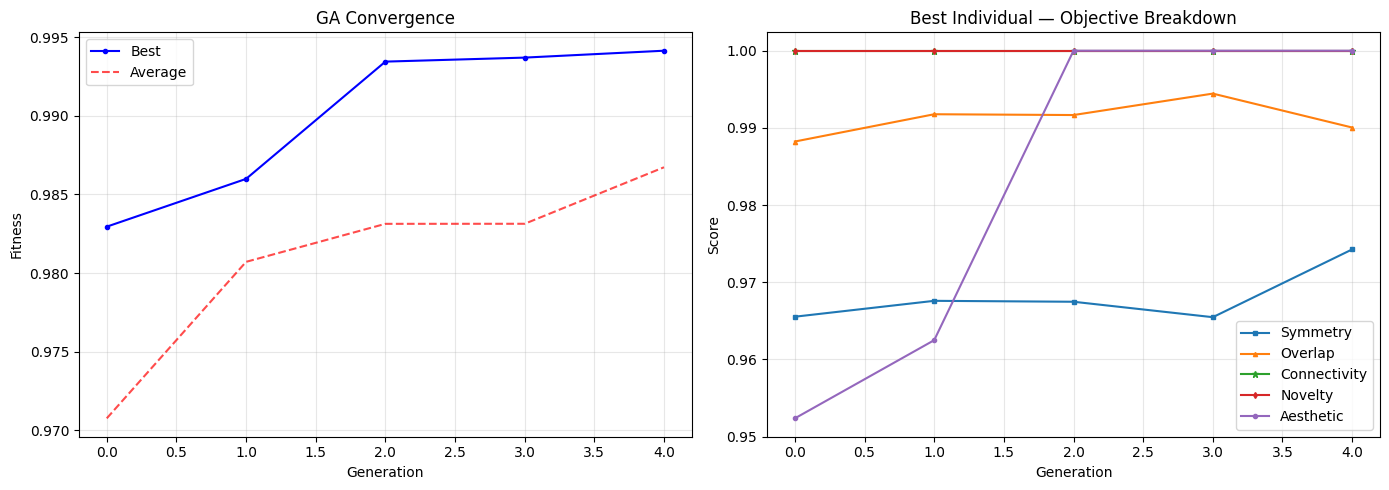

In [16]:
# ============================================================
# Plot GA convergence
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall fitness
ax = axes[0]
ax.plot(history['best_fitness'], 'b-o', label='Best', markersize=3)
ax.plot(history['avg_fitness'], 'r--', label='Average', alpha=0.7)
ax.set_xlabel('Generation')
ax.set_ylabel('Fitness')
ax.set_title('GA Convergence')
ax.legend()
ax.grid(True, alpha=0.3)

# Per-objective breakdown
ax = axes[1]
ax.plot(history['best_symmetry'], label='Symmetry', marker='s', markersize=3)
ax.plot(history['best_overlap'], label='Overlap', marker='^', markersize=3)
ax.plot(history['best_connectivity'], label='Connectivity', marker='*', markersize=5)
ax.plot(history['best_novelty'], label='Novelty', marker='d', markersize=3)
ax.plot(history['best_aesthetic'], label='Aesthetic', marker='o', markersize=3)
ax.set_xlabel('Generation')
ax.set_ylabel('Score')
ax.set_title('Best Individual — Objective Breakdown')
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 9. Visualize Top Designs


Rank #1 | Fitness: 0.9945
  Genes: [329, 379, 273, 135, 449, 779, 435, 469]
  Sources: ['chair_0329', 'chair_0379', 'chair_0273', 'chair_0135', 'chair_0449', 'chair_0779', 'chair_0435', 'chair_0469']
  Symmetry=0.974  Overlap=0.992  Connectivity=1.000  Novelty=1.000  Aesthetic=1.000


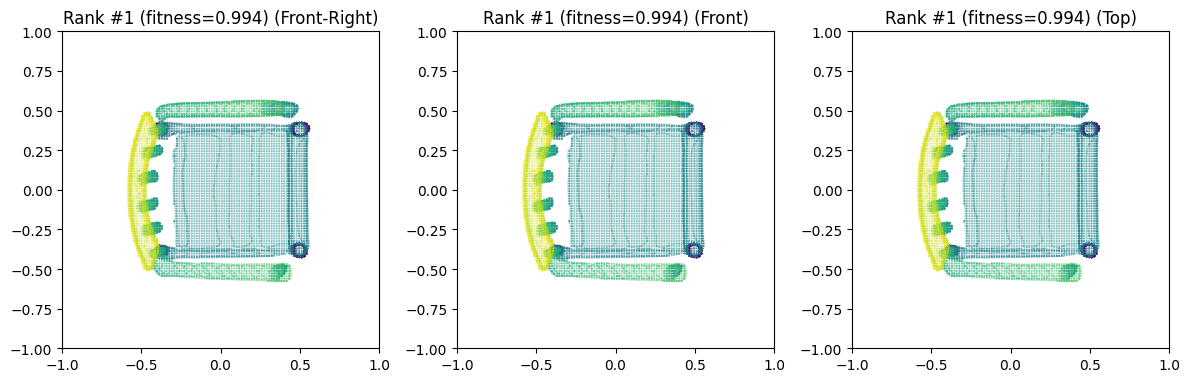

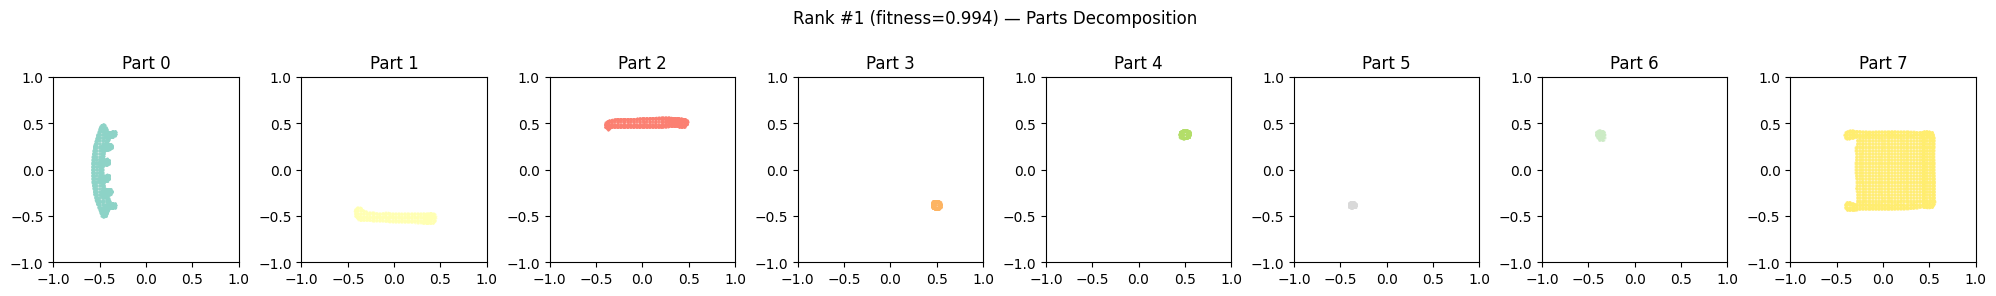


Rank #2 | Fitness: 0.9941
  Genes: [510, 379, 273, 135, 449, 779, 435, 469]
  Sources: ['chair_0510', 'chair_0379', 'chair_0273', 'chair_0135', 'chair_0449', 'chair_0779', 'chair_0435', 'chair_0469']
  Symmetry=0.974  Overlap=0.990  Connectivity=1.000  Novelty=1.000  Aesthetic=1.000


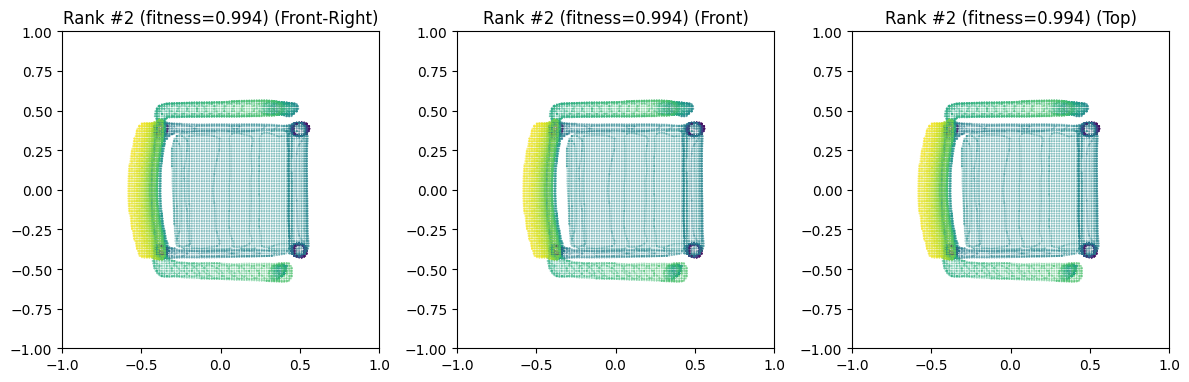

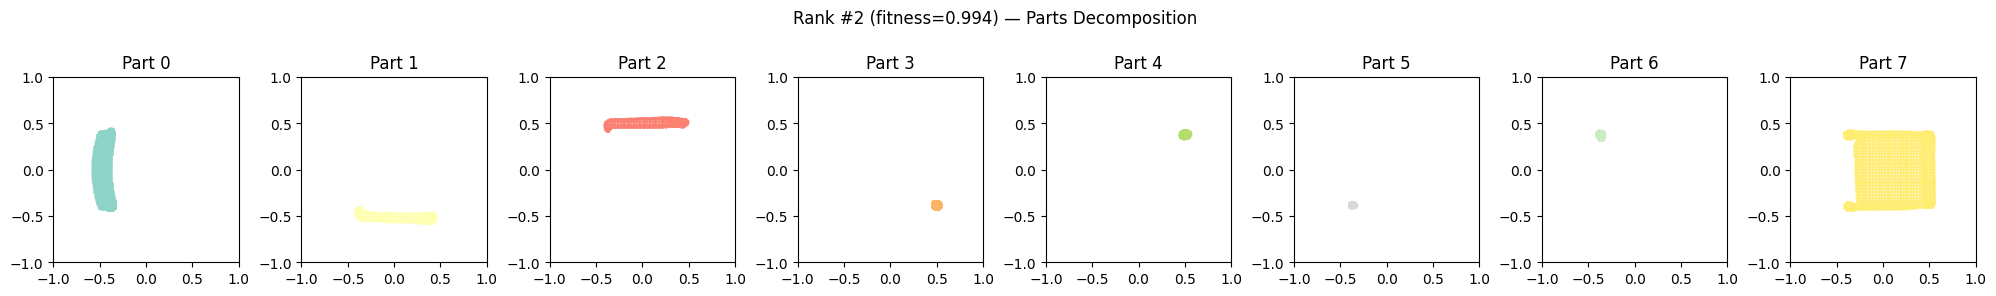


Rank #3 | Fitness: 0.9940
  Genes: [510, 379, 273, 135, 449, 779, 712, 469]
  Sources: ['chair_0510', 'chair_0379', 'chair_0273', 'chair_0135', 'chair_0449', 'chair_0779', 'chair_0712', 'chair_0469']
  Symmetry=0.973  Overlap=0.990  Connectivity=1.000  Novelty=1.000  Aesthetic=1.000


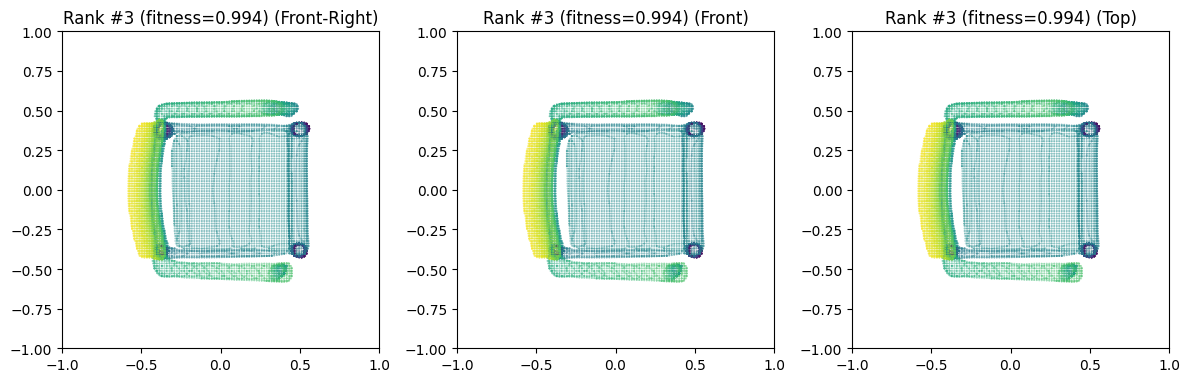

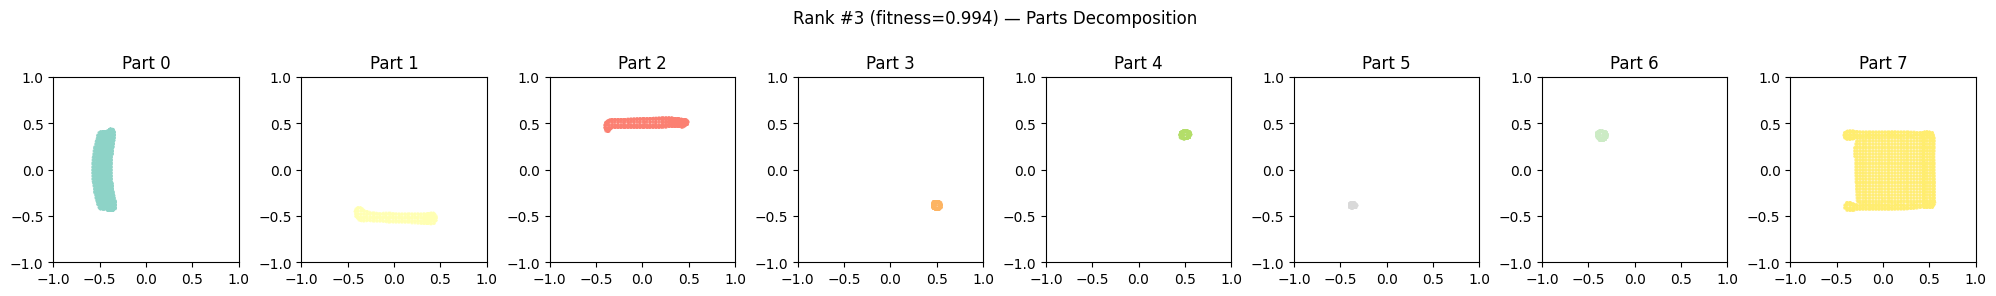


Rank #4 | Fitness: 0.9937
  Genes: [546, 860, 777, 135, 449, 779, 938, 469]
  Sources: ['chair_0546', 'chair_0860', 'chair_0777', 'chair_0135', 'chair_0449', 'chair_0779', 'chair_0938', 'chair_0469']
  Symmetry=0.965  Overlap=0.994  Connectivity=1.000  Novelty=1.000  Aesthetic=1.000


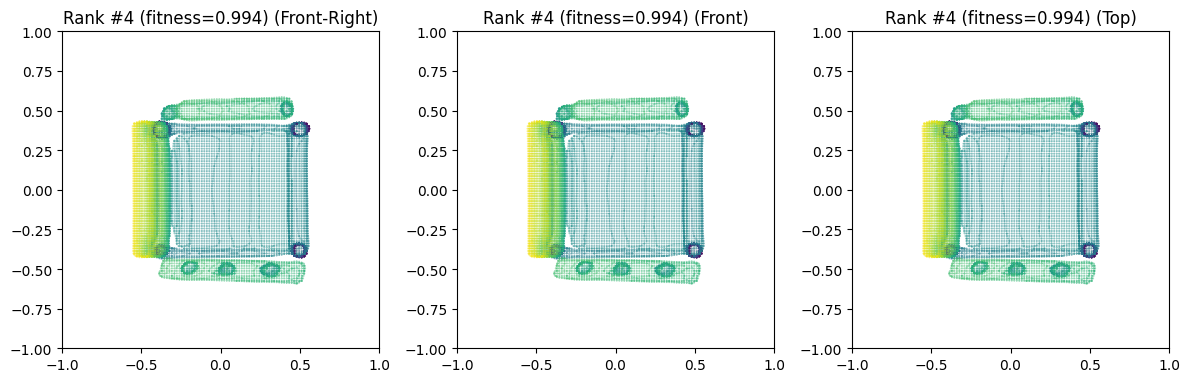

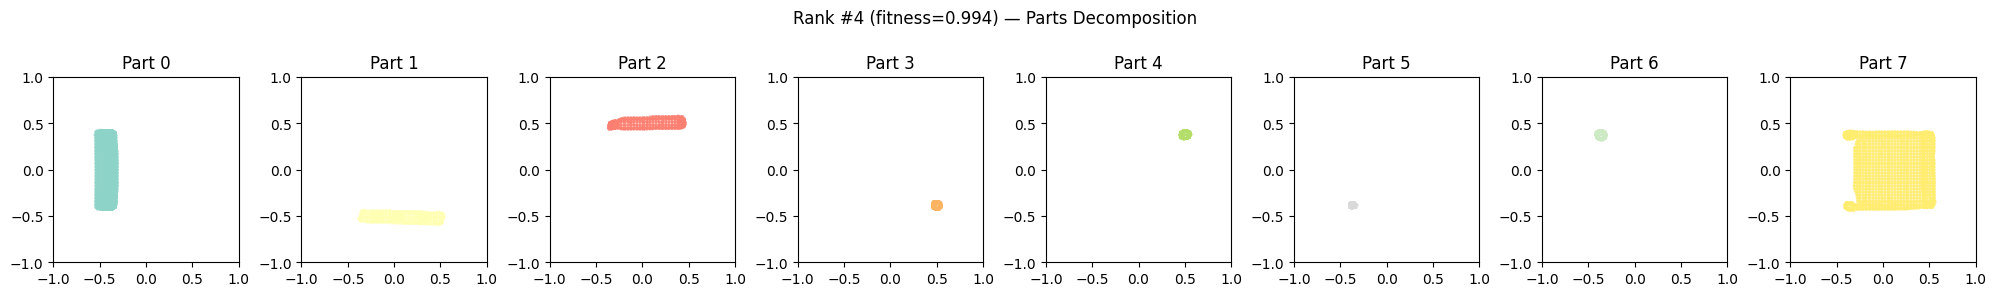


Rank #5 | Fitness: 0.9933
  Genes: [469, 379, 273, 552, 449, 779, 968, 334]
  Sources: ['chair_0469', 'chair_0379', 'chair_0273', 'chair_0552', 'chair_0449', 'chair_0779', 'chair_0968', 'chair_0334']
  Symmetry=0.968  Overlap=0.990  Connectivity=1.000  Novelty=1.000  Aesthetic=1.000


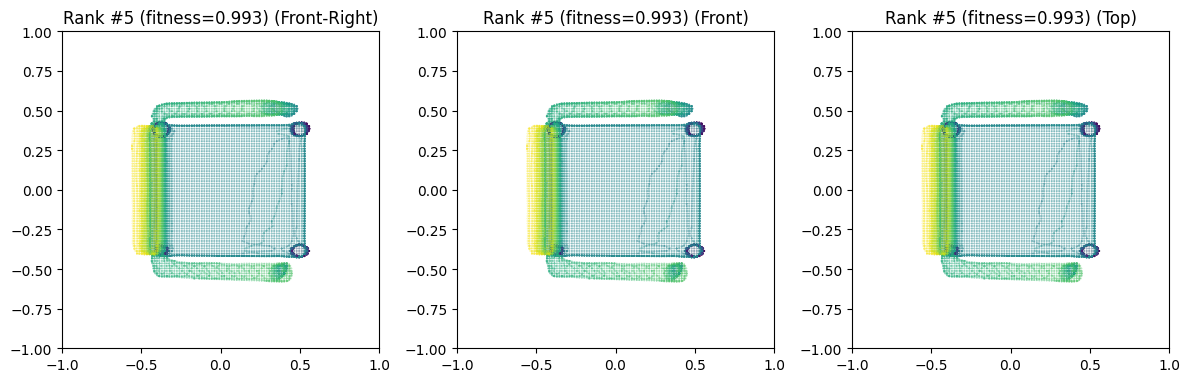

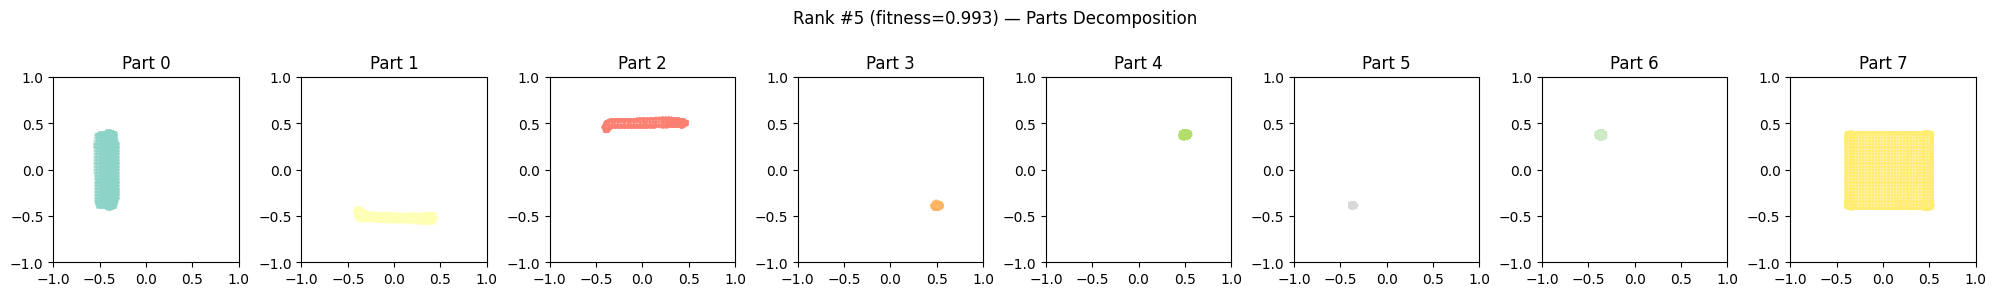

In [15]:
# ============================================================
# Visualize top-K designs at higher resolution
# ============================================================
# Reuses `grid_filler` (res=128) from section 1 — no need for a separate hi-res filler.
TOP_K = 5

for rank, chrom in enumerate(population[:TOP_K]):
    print(f"\n{'='*60}")
    print(f"Rank #{rank+1} | Fitness: {chrom.fitness:.4f}")
    print(f"  Genes: {chrom.genes}")
    print(f"  Sources: {[instances[g] for g in chrom.genes]}")
    print(f"  Symmetry={chrom.fitness_details['symmetry']:.3f}  "
          f"Overlap={chrom.fitness_details['overlap']:.3f}  "
          f"Connectivity={chrom.fitness_details['connectivity']:.3f}  "
          f"Novelty={chrom.fitness_details['novelty']:.3f}  "
          f"Aesthetic={chrom.fitness_details['aesthetic']:.3f}")

    lat, R, t, s = chromosome_to_latent_pose(chrom)
    mesh, parts = decode_chair(lat, R, t, s, resolution=128)
    visualize_chair(mesh, parts, title=f"Rank #{rank+1} (fitness={chrom.fitness:.3f})")

## 10. Compare: Best GA Design vs Source Chairs

Show which training chairs contributed parts to the best design.

Best design uses parts from 8 different chairs:
  Chair 135 (chair_0135): parts [3]
  Chair 273 (chair_0273): parts [2]
  Chair 329 (chair_0329): parts [0]
  Chair 379 (chair_0379): parts [1]
  Chair 435 (chair_0435): parts [6]
  Chair 449 (chair_0449): parts [4]
  Chair 469 (chair_0469): parts [7]
  Chair 779 (chair_0779): parts [5]


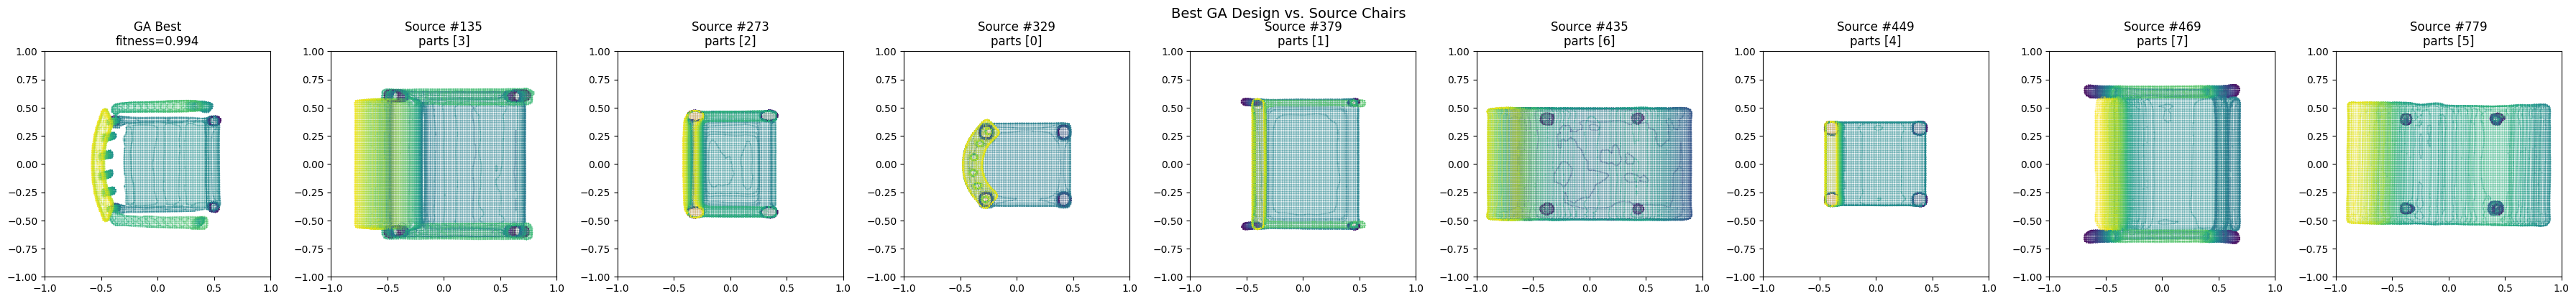

In [17]:
# ============================================================
# Show source chairs that contributed to the best design
# ============================================================
best_chrom = population[0]
source_chairs = sorted(set(best_chrom.genes))

print(f"Best design uses parts from {len(source_chairs)} different chairs:")
for chair_idx in source_chairs:
    parts_from = [p for p in range(n_parts) if best_chrom.genes[p] == chair_idx]
    print(f"  Chair {chair_idx} ({instances[chair_idx]}): parts {parts_from}")

# Visualize source chairs
n_sources = len(source_chairs)
fig, axes = plt.subplots(1, n_sources + 1, figsize=(4 * (n_sources + 1), 4))

# Best design
lat_best, R_best, t_best, s_best = chromosome_to_latent_pose(best_chrom)
mesh_best, _ = decode_chair(lat_best, R_best, t_best, s_best)
ax = axes[0]
if not mesh_best.is_empty:
    v = mesh_best.vertices
    ax.scatter(v[:, 0], v[:, 2], c=v[:, 1], cmap='viridis', s=0.2, alpha=0.5)
ax.set_title(f"GA Best\nfitness={best_chrom.fitness:.3f}")
ax.set_aspect('equal')
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)

# Source chairs
for i, chair_idx in enumerate(source_chairs):
    lat_src = latents(torch.tensor([chair_idx]).to(device))
    if use_poses:
        R_src, t_src, s_src = poses(torch.tensor([chair_idx]).to(device))
    else:
        R_src, t_src, s_src = None, None, None
    mesh_src, _ = decode_chair(lat_src, R_src, t_src, s_src)

    ax = axes[i + 1]
    if not mesh_src.is_empty:
        v = mesh_src.vertices
        ax.scatter(v[:, 0], v[:, 2], c=v[:, 1], cmap='viridis', s=0.2, alpha=0.5)
    parts_from = [p for p in range(n_parts) if best_chrom.genes[p] == chair_idx]
    ax.set_title(f"Source #{chair_idx}\nparts {parts_from}")
    ax.set_aspect('equal')
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)

fig.suptitle("Best GA Design vs. Source Chairs", fontsize=14)
fig.tight_layout()
plt.show()

## 11. Export Best Designs as OBJ Meshes

In [18]:
# ============================================================
# Export top designs as OBJ files + PNG snapshots
# ============================================================
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

output_dir = os.path.join(PARTSDF_ROOT, "notebooks", "ga_chair_generation", "output")
os.makedirs(output_dir, exist_ok=True)

N_EXPORT = 5
SNAPSHOT_DPI = 150


def _render_mesh_ax(ax, mesh, color=None, alpha=0.9):
    """Render a trimesh on a matplotlib 3D axes using Poly3DCollection."""
    if mesh.is_empty:
        return
    tris = mesh.vertices[mesh.faces]  # (F, 3, 3)
    coll = Poly3DCollection(tris, alpha=alpha, linewidths=0.1)
    if color is not None:
        coll.set_facecolor(color)
        coll.set_edgecolor((0, 0, 0, 0.15))
    ax.add_collection3d(coll)


def render_snapshot(mesh, parts, out_path, title=None):
    """Save a single PNG snapshot: 3 angles + colored-parts view (2x2 grid).
    Data is Y-up, so we map (x, z, y) → matplotlib (x, y, z) for natural viewing."""
    fig = plt.figure(figsize=(10, 10))
    part_colors = plt.cm.Set3(np.linspace(0, 1, n_parts))

    # Three camera angles for the full mesh
    views = [
        ("Perspective", 20, 45),
        ("Front",       0, 0),
        ("Side",        0, 90),
    ]

    # Remap vertices once per mesh: (x, y_up, z) → (x, z, y_up) so z-axis points up in mpl
    def remap(m):
        if m.is_empty:
            return m
        m2 = m.copy()
        v = m2.vertices
        m2.vertices = np.stack([v[:, 0], v[:, 2], v[:, 1]], axis=1)
        return m2

    mesh_r = remap(mesh)
    parts_r = [remap(p) for p in parts]

    # Panels 1-3: full mesh from different angles
    for i, (label, elev, azim) in enumerate(views):
        ax = fig.add_subplot(2, 2, i + 1, projection='3d')
        _render_mesh_ax(ax, mesh_r, color=(0.55, 0.70, 0.88), alpha=0.95)
        ax.set_title(label, fontsize=10)
        ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
        ax.set_box_aspect((1, 1, 1))
        ax.view_init(elev=elev, azim=azim)
        ax.set_axis_off()

    # Panel 4: parts colored
    ax = fig.add_subplot(2, 2, 4, projection='3d')
    for i, part in enumerate(parts_r):
        _render_mesh_ax(ax, part, color=part_colors[i], alpha=0.9)
    ax.set_title("Parts", fontsize=10)
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=20, azim=45)
    ax.set_axis_off()

    if title:
        fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    fig.savefig(out_path, dpi=SNAPSHOT_DPI, bbox_inches='tight')
    plt.close(fig)


for rank, chrom in enumerate(population[:N_EXPORT]):
    lat, R, t, s = chromosome_to_latent_pose(chrom)

    # Full mesh
    mesh, parts = decode_chair(lat, R, t, s, resolution=128)
    mesh_fn = os.path.join(output_dir, f"ga_rank{rank+1}_full.obj")
    if not mesh.is_empty:
        mesh.export(mesh_fn)
        print(f"Exported: {mesh_fn}")

    # Colored parts
    colored_parts = trimesh.util.concatenate(get_color_parts(parts))
    parts_fn = os.path.join(output_dir, f"ga_rank{rank+1}_parts.obj")
    if not colored_parts.is_empty:
        colored_parts.export(parts_fn)
        print(f"Exported: {parts_fn}")

    # Individual parts
    for p_idx, part in enumerate(parts):
        if not part.is_empty:
            part_fn = os.path.join(output_dir, f"ga_rank{rank+1}_part{p_idx}.obj")
            part.export(part_fn)

    # PNG snapshot (2x2 grid: 3 angles + parts)
    png_fn = os.path.join(output_dir, f"ga_rank{rank+1}.png")
    title = (f"Rank #{rank+1}  fitness={chrom.fitness:.3f}  "
             f"(sym={chrom.fitness_details['symmetry']:.2f} "
             f"ovl={chrom.fitness_details['overlap']:.2f} "
             f"con={chrom.fitness_details['connectivity']:.2f} "
             f"nov={chrom.fitness_details['novelty']:.2f} "
             f"aes={chrom.fitness_details['aesthetic']:.2f})")
    render_snapshot(mesh, parts, png_fn, title=title)
    print(f"Exported: {png_fn}")

    # Save chromosome info
    info = {
        'rank': rank + 1,
        'genes': chrom.genes,
        'pose_anchor': chrom.pose_anchor,
        'source_instances': [instances[g] for g in chrom.genes],
        'fitness': chrom.fitness,
        'fitness_details': chrom.fitness_details,
    }
    info_fn = os.path.join(output_dir, f"ga_rank{rank+1}_info.json")
    with open(info_fn, 'w') as f:
        json.dump(info, f, indent=2)

print(f"\nAll exports saved to: {output_dir}")

Exported: /home/user/bodyawarechair/PartSDF/notebooks/ga_chair_generation/output/ga_rank1_full.obj
Exported: /home/user/bodyawarechair/PartSDF/notebooks/ga_chair_generation/output/ga_rank1_parts.obj
Exported: /home/user/bodyawarechair/PartSDF/notebooks/ga_chair_generation/output/ga_rank1.png
Exported: /home/user/bodyawarechair/PartSDF/notebooks/ga_chair_generation/output/ga_rank2_full.obj
Exported: /home/user/bodyawarechair/PartSDF/notebooks/ga_chair_generation/output/ga_rank2_parts.obj
Exported: /home/user/bodyawarechair/PartSDF/notebooks/ga_chair_generation/output/ga_rank2.png
Exported: /home/user/bodyawarechair/PartSDF/notebooks/ga_chair_generation/output/ga_rank3_full.obj
Exported: /home/user/bodyawarechair/PartSDF/notebooks/ga_chair_generation/output/ga_rank3_parts.obj
Exported: /home/user/bodyawarechair/PartSDF/notebooks/ga_chair_generation/output/ga_rank3.png
Exported: /home/user/bodyawarechair/PartSDF/notebooks/ga_chair_generation/output/ga_rank4_full.obj
Exported: /home/user/b

In [19]:
# ============================================================
# Source-chair collage — for each top design, render the GA result
# alongside every source chair that contributed a part + the pose anchor.
# Saved as ga_rank{K}_sources.png.
# ============================================================

def _render_mesh_single(ax, mesh, color=(0.55, 0.70, 0.88), elev=20, azim=45):
    """Draw a trimesh onto one 3D axis in Y-up → Z-up remapped coords."""
    if mesh.is_empty:
        ax.text2D(0.5, 0.5, "(empty)", ha='center', va='center', transform=ax.transAxes)
    else:
        v = mesh.vertices
        v_r = np.stack([v[:, 0], v[:, 2], v[:, 1]], axis=1)
        tris = v_r[mesh.faces]
        coll = Poly3DCollection(tris, alpha=0.95, linewidths=0.1)
        coll.set_facecolor(color)
        coll.set_edgecolor((0, 0, 0, 0.15))
        ax.add_collection3d(coll)
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=elev, azim=azim)
    ax.set_axis_off()


def render_sources_collage(chrom, out_path, rank_label="?", resolution=96):
    """Render the GA design + every unique source chair + pose anchor as one PNG.
    Each source tile is labeled with which part indices it contributed."""
    sources = sorted(set(chrom.genes))
    pose_anchor_distinct = chrom.pose_anchor not in sources

    # Decode GA design
    lat_ga, R_ga, t_ga, s_ga = chromosome_to_latent_pose(chrom)
    mesh_ga, _ = decode_chair(lat_ga, R_ga, t_ga, s_ga, resolution=resolution)

    # Decode source chairs using each chair's own pose
    src_meshes = []
    for sid in sources:
        lat_s = latents(torch.tensor([sid]).to(device))
        if use_poses:
            R_s, t_s, s_s = poses(torch.tensor([sid]).to(device))
        else:
            R_s, t_s, s_s = None, None, None
        m, _ = decode_chair(lat_s, R_s, t_s, s_s, resolution=resolution)
        parts_from = [p for p in range(n_parts) if chrom.genes[p] == sid]
        src_meshes.append((sid, m, parts_from))

    anchor_mesh = None
    if pose_anchor_distinct:
        a = chrom.pose_anchor
        lat_a = latents(torch.tensor([a]).to(device))
        if use_poses:
            R_a, t_a, s_a = poses(torch.tensor([a]).to(device))
        else:
            R_a, t_a, s_a = None, None, None
        anchor_mesh, _ = decode_chair(lat_a, R_a, t_a, s_a, resolution=resolution)

    # Layout: 1 GA + N sources + (0 or 1) anchor
    n_tiles = 1 + len(src_meshes) + (1 if anchor_mesh is not None else 0)
    n_cols = min(5, n_tiles)
    n_rows = (n_tiles + n_cols - 1) // n_cols
    fig = plt.figure(figsize=(3.2 * n_cols, 3.2 * n_rows))

    # Tile 1: GA design (orange to stand out)
    ax = fig.add_subplot(n_rows, n_cols, 1, projection='3d')
    _render_mesh_single(ax, mesh_ga, color=(0.92, 0.55, 0.35))
    ax.set_title(f"GA Rank #{rank_label}\nfitness={chrom.fitness:.3f}", fontsize=9)

    # Tiles 2..N+1: source chairs
    for i, (sid, m, parts_from) in enumerate(src_meshes):
        ax = fig.add_subplot(n_rows, n_cols, i + 2, projection='3d')
        _render_mesh_single(ax, m)
        ax.set_title(f"chair_{sid:04d}\nparts {parts_from}", fontsize=9)

    # Last tile: pose anchor (if different from all sources)
    if anchor_mesh is not None:
        ax = fig.add_subplot(n_rows, n_cols, n_tiles, projection='3d')
        _render_mesh_single(ax, anchor_mesh, color=(0.55, 0.80, 0.55))
        ax.set_title(f"pose anchor\nchair_{chrom.pose_anchor:04d}", fontsize=9)

    anchor_note = f" + anchor chair_{chrom.pose_anchor:04d}" if pose_anchor_distinct else ""
    fig.suptitle(f"Rank #{rank_label} — parts from {len(sources)} chair(s){anchor_note}",
                 fontsize=11)
    fig.tight_layout()
    fig.savefig(out_path, dpi=SNAPSHOT_DPI, bbox_inches='tight')
    plt.close(fig)


# Save a source collage for every exported design
for rank, chrom in enumerate(population[:N_EXPORT]):
    src_fn = os.path.join(output_dir, f"ga_rank{rank+1}_sources.png")
    render_sources_collage(chrom, src_fn, rank_label=str(rank + 1))
    print(f"Exported: {src_fn}")

print(f"\nSource collages saved to: {output_dir}")

Exported: /home/user/bodyawarechair/PartSDF/notebooks/ga_chair_generation/output/ga_rank1_sources.png
Exported: /home/user/bodyawarechair/PartSDF/notebooks/ga_chair_generation/output/ga_rank2_sources.png
Exported: /home/user/bodyawarechair/PartSDF/notebooks/ga_chair_generation/output/ga_rank3_sources.png
Exported: /home/user/bodyawarechair/PartSDF/notebooks/ga_chair_generation/output/ga_rank4_sources.png
Exported: /home/user/bodyawarechair/PartSDF/notebooks/ga_chair_generation/output/ga_rank5_sources.png

Source collages saved to: /home/user/bodyawarechair/PartSDF/notebooks/ga_chair_generation/output


## 12. Population Diversity Analysis

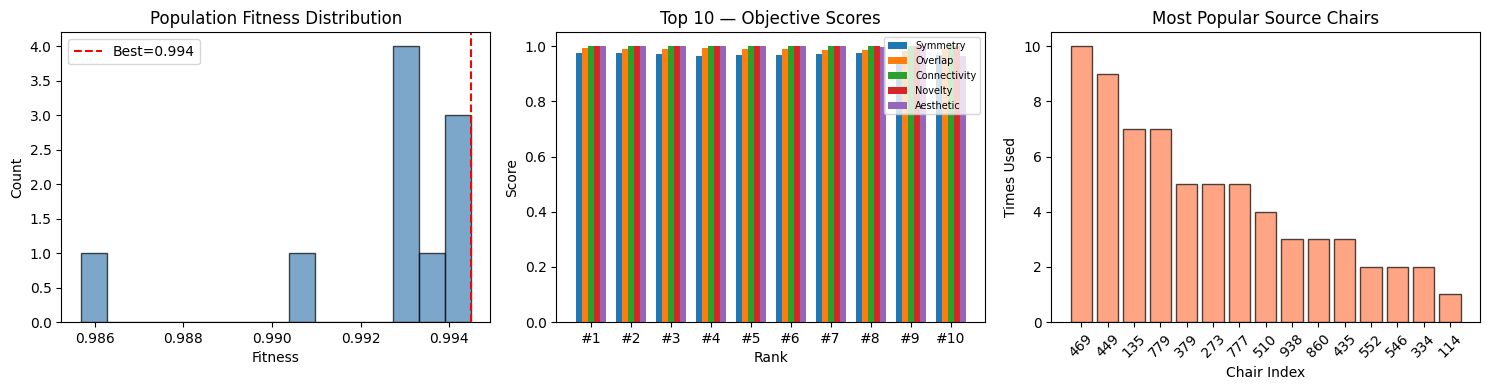


Population uses 27 unique source chairs out of 1065 available.


In [20]:
# ============================================================
# Analyze final population diversity
# ============================================================

# Fitness distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram of fitness
ax = axes[0]
fitnesses = [c.fitness for c in population]
ax.hist(fitnesses, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(population[0].fitness, color='red', linestyle='--', label=f'Best={population[0].fitness:.3f}')
ax.set_xlabel('Fitness')
ax.set_ylabel('Count')
ax.set_title('Population Fitness Distribution')
ax.legend()

# Per-objective scores of top 10
ax = axes[1]
top10 = population[:10]
x = range(len(top10))
width = 0.15
ax.bar([i - 2*width for i in x], [c.fitness_details['symmetry'] for c in top10], width, label='Symmetry')
ax.bar([i - width for i in x],   [c.fitness_details['overlap'] for c in top10], width, label='Overlap')
ax.bar([i for i in x],           [c.fitness_details['connectivity'] for c in top10], width, label='Connectivity')
ax.bar([i + width for i in x],   [c.fitness_details['novelty'] for c in top10], width, label='Novelty')
ax.bar([i + 2*width for i in x], [c.fitness_details['aesthetic'] for c in top10], width, label='Aesthetic')
ax.set_xlabel('Rank')
ax.set_ylabel('Score')
ax.set_title('Top 10 — Objective Scores')
ax.legend(fontsize=7)
ax.set_xticks(list(x))
ax.set_xticklabels([f'#{i+1}' for i in x])

# Gene diversity: which chairs are most used?
ax = axes[2]
all_genes = []
for c in population:
    all_genes.extend(c.genes)
unique_genes, counts = np.unique(all_genes, return_counts=True)
top_genes_idx = np.argsort(-counts)[:15]
ax.bar(range(len(top_genes_idx)), counts[top_genes_idx], color='coral', edgecolor='black', alpha=0.7)
ax.set_xticks(range(len(top_genes_idx)))
ax.set_xticklabels([str(unique_genes[i]) for i in top_genes_idx], rotation=45)
ax.set_xlabel('Chair Index')
ax.set_ylabel('Times Used')
ax.set_title('Most Popular Source Chairs')

fig.tight_layout()
plt.show()

print(f"\nPopulation uses {len(np.unique(all_genes))} unique source chairs out of {n_shapes} available.")

## 13. User-Specified Design Rules (Optional)

You can add custom constraints here. Examples:
- "Part 0 must come from a specific chair"
- "Parts 1 and 2 must come from the same chair" (e.g., matching legs)
- "Minimum 3 different source chairs"

In [ ]:
# ============================================================
# User-specified design rules
# ============================================================

# Define your rules here:
DESIGN_RULES = {
    # Groups of parts that should come from the same chair
    # e.g., if parts 0,1,2,3 are legs, they should match
    'same_source_groups': [
        # [0, 1],  # example: parts 0 and 1 must share source
        # [2, 3],  # example: parts 2 and 3 must share source
    ],

    # Parts that must come from a specific chair index
    'fixed_parts': {
        # 0: 5,   # example: part 0 must come from chair 5
    },

    # Minimum number of unique source chairs
    'min_unique_sources': 2,

    # Maximum number of unique source chairs (to avoid too chaotic designs)
    'max_unique_sources': n_parts,
}


def check_design_rules(chrom: Chromosome) -> float:
    """
    Check user-specified design rules. Returns a penalty in [0, 1]
    where 0 = all rules satisfied, 1 = max violation.
    """
    violations = 0
    total_rules = 0

    # Same-source groups
    for group in DESIGN_RULES['same_source_groups']:
        total_rules += 1
        sources = set(chrom.genes[p] for p in group)
        if len(sources) > 1:
            violations += 1

    # Fixed parts
    for part_idx, required_chair in DESIGN_RULES['fixed_parts'].items():
        total_rules += 1
        if chrom.genes[part_idx] != required_chair:
            violations += 1

    # Unique sources range
    unique = len(set(chrom.genes))
    if DESIGN_RULES['min_unique_sources'] > 0:
        total_rules += 1
        if unique < DESIGN_RULES['min_unique_sources']:
            violations += 1
    if DESIGN_RULES['max_unique_sources'] < n_parts:
        total_rules += 1
        if unique > DESIGN_RULES['max_unique_sources']:
            violations += 1

    if total_rules == 0:
        return 0.0
    return violations / total_rules


def evaluate_fitness_with_rules(chrom: Chromosome) -> float:
    """Fitness with user rules as an additional penalty."""
    base_fitness = evaluate_fitness(chrom)
    rule_penalty = check_design_rules(chrom)
    # Apply penalty: reduce fitness by up to 50% for rule violations
    adjusted = base_fitness * (1.0 - 0.5 * rule_penalty)
    chrom.fitness = adjusted
    chrom.fitness_details['rule_penalty'] = rule_penalty
    return adjusted


print("Design rules defined.")
print(f"Rules: {DESIGN_RULES}")

# To re-run GA with rules, set evaluate_fn=evaluate_fitness_with_rules
# in the GA loop above (replace evaluate_fitness calls)

## 14. Interactive: Manual Part Mixing

Try mixing parts manually to build your own custom chair.

In [ ]:
# ============================================================
# Manual part mixing — edit the genes list below
# ============================================================

# Specify which chair to take each part from:
manual_genes = [0] * n_parts  # <-- EDIT THIS! e.g., [0, 3, 3, 5, 5, 2, 2, 1]

manual_chrom = Chromosome(genes=manual_genes)
evaluate_fitness(manual_chrom)

print(f"Manual design genes: {manual_chrom.genes}")
print(f"Fitness: {manual_chrom.fitness:.4f}")
print(f"Details: {manual_chrom.fitness_details}")

lat, R, t, s = chromosome_to_latent_pose(manual_chrom)
mesh, parts = decode_chair(lat, R, t, s, resolution=128)
visualize_chair(mesh, parts, title="Manual Design")

## 15. Summary

### What this notebook does:
1. **Loads** a pre-trained PartSDF model that decomposes chairs into 8 semantic parts
2. **Extracts** per-part latent codes and poses from the training set as a "part library"
3. **Defines** a multi-objective fitness function (symmetry, overlap, **connectivity**, novelty, aesthetic)
4. **Runs** a Genetic Algorithm to find optimal part combinations
5. **Visualizes** and **exports** the generated novel chair designs (OBJ + PNG snapshot + source-chair collage)

### Fitness objectives (5):
| Objective | Weight | What it measures |
|-----------|--------|-----------------|
| Symmetry | 0.15 | Left-right SDF symmetry (reuses precomputed part SDFs — 1 model pass instead of 2) |
| Overlap | 0.20 | Penalizes excessive part intersection |
| **Connectivity** | **0.30** | **Parts must be physically touching — checks pairwise surface contact and verifies all parts form a single connected component via BFS** |
| Novelty | 0.15 | Parts from diverse source chairs |
| Aesthetic | 0.20 | Spatial distribution, active parts, source diversity |

### Connectivity scoring detail:
- For each pair of active parts, check if both surfaces pass near the same grid points (`|SDF| < CONNECTIVITY_THRESH_VOXELS * voxel_size`, default `1.0`)
- Build an adjacency graph from these contacts
- BFS from one part: score = fraction of parts reachable = `connected / total_active`
- Score 1.0 = all parts form one connected body; 0.5 = half the parts are floating

### Tuning tips:
- Adjust `W_SYMMETRY`, `W_OVERLAP`, `W_CONNECTIVITY`, `W_NOVELTY`, `W_AESTHETIC` weights
- `CONNECTIVITY_THRESH_VOXELS` (default 1.0) controls how close surfaces must be to count as "touching" — raise it to be more lenient
- Increase `population_size` and `n_generations` for better results (slower)
- `EVAL_RES` controls fitness evaluation speed vs accuracy (32 = fast, 48+ = more precise)

### Coordinate system note:
PartSDF training data is Y-up. The PNG snapshot renderer remaps to Z-up for natural matplotlib viewing. If you plug in a custom asset (which per project convention is Z-up), convert it to Y-up before feeding it through `chromosome_to_latent_pose`.

### Outputs per design (in `output/`):
- `ga_rank{K}_full.obj` — merged mesh
- `ga_rank{K}_parts.obj` — colored parts in one file
- `ga_rank{K}_part{P}.obj` — individual parts
- `ga_rank{K}.png` — 2×2 snapshot (perspective / front / side / colored parts)
- `ga_rank{K}_sources.png` — GA result + every source chair + pose anchor, each tile labeled with contributed part indices
- `ga_rank{K}_info.json` — genes, source instances, fitness breakdown